In [16]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/fantasticboy123/assign-ml/dataset.csv


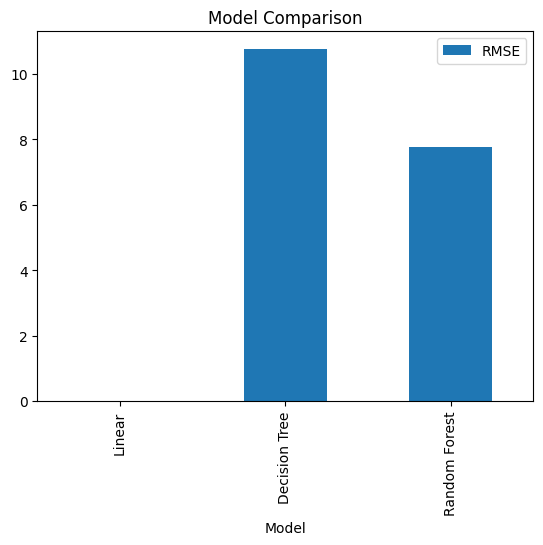

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/fantasticboy123/assign-ml/dataset.csv")

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Convert categorical
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Success_Percentage', axis=1)
y = df['Success_Percentage']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

results = []

import numpy as np

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, pred)

    results.append([name, rmse, r2])

res = pd.DataFrame(results, columns=["Model","RMSE","R2"])
res.to_csv("table_RQ7.csv", index=False)

res.plot(x='Model', y='RMSE', kind='bar')
plt.title("Model Comparison")
plt.savefig("figure_RQ7.pdf")
plt.show()